# 06 - model evaluation (sample)

evaluate svm on sample data: per-class metrics, error analysis.

In [ ]:
import joblib, pandas as pd, numpy as np, librosa
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

import sys
sys.path.append('../../')
from src.config.settings import SAMPLES, FIGURES_DIR
from src.utils.feature_engineering import extract_mfcc

In [2]:
df = pd.read_csv(SAMPLES / "sample_labels.csv")
df.head()

,filepath,channel,emotion_code,emotion,intensity,statement,repetition,actor,gender,split
0,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,1,1,23,male,test
1,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,1,2,23,male,test
2,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,2,1,23,male,test
3,/mnt/d/career/projects/lightweight-speech-emot...,song,1,neutral,normal,2,2,23,male,test
4,/mnt/d/career/projects/lightweight-speech-emot...,song,2,calm,normal,1,1,23,male,test


In [3]:
svm = joblib.load(SAMPLES / "svm_baseline_sample.pkl")

In [4]:
test = df[df['split']=='test']


In [5]:
X_test = np.array([extract_mfcc(fp) for fp in test['filepath']])
y_test = test['emotion_code'].values

In [6]:
scaler = StandardScaler().fit(X_test)
y_pred = svm.predict(scaler.transform(X_test))

In [7]:
emap = {1:'neutral',2:'calm',3:'happy',4:'sad',5:'angry',6:'fearful',7:'disgust',8:'surprised'}

In [8]:
print(classification_report(np.asarray(y_test), y_pred, target_names=list(emap.values()), digits=3))

              precision    recall  f1-score   support

     neutral      0.000     0.000     0.000         8
        calm      0.857     0.375     0.522        16
       happy      0.333     0.500     0.400        16
         sad      0.300     0.188     0.231        16
       angry      0.353     0.375     0.364        16
     fearful      0.207     0.375     0.267        16
     disgust      0.375     0.375     0.375         8
   surprised      0.000     0.000     0.000         8

    accuracy                          0.308       104
   macro avg      0.303     0.273     0.270       104
weighted avg      0.344     0.308     0.303       104



/home/aang/miniconda3/envs/speechrecog/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aang/miniconda3/envs/speechrecog/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aang/miniconda3/envs/speechrecog/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

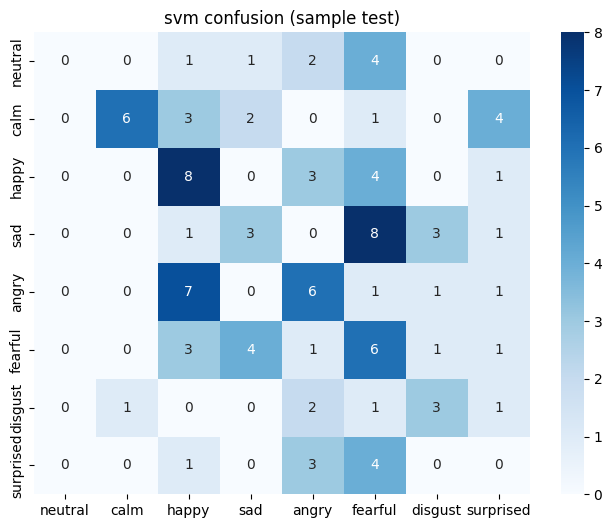

correct: 32/104 (30.8%)


In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(emap.values()), yticklabels=list(emap.values()))
plt.title('svm confusion (sample test)')
plt.savefig(str(FIGURES_DIR / 'fig01-svm-confusion-matrix.png'), dpi=120, bbox_inches='tight')
plt.show()
tp = np.trace(cm)
print(f"correct: {tp}/{len(y_test)} ({tp/len(y_test)*100:.1f}%)")

evaluation complete. confusion matrix shows which emotions the model confuses.